In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bike-sharing-demand/sampleSubmission.csv
/kaggle/input/bike-sharing-demand/train.csv
/kaggle/input/bike-sharing-demand/test.csv


# Bicycle Demand Prediction

## Data Exploration

In [29]:
import numpy as np       # 넘파이 임포트
import pandas as pd      # 판다스 임포트

data_path = '/kaggle/input/bike-sharing-demand/'             # 데이터 경로

train = pd.read_csv(data_path + 'train.csv')                 # 훈련 데이터
test = pd.read_csv(data_path + 'test.csv')                   # 테스트 데이터

submission = pd.read_csv(data_path + 'sampleSubmission.csv') # 제출 샘플 데이터

print(train.shape)
print(test.shape)
print(train.columns)
print()
print(train.head())
print()
print(test.head())

(10886, 12)
(6493, 9)
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

              datetime  s

In [30]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None


In [31]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB
None


### DateTime Feature Engineering

In [32]:
train['date'] = train['datetime'].apply(lambda x: x.split()[0]) # 날짜 피처 생성

# 연도, 월, 일, 시, 분, 초 피처를 차례로 생성
train['year'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[0])
train['month'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[1])
train['day'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[2])
train['hour'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[0])
train['minute'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[1])
train['second'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[2])

In [33]:
from datetime import datetime  # datetime 라이브러리 임포트
import calendar

print(train['date'][100]) # 날짜 
print(datetime.strptime(train['date'][100], '%Y-%m-%d'))  # datetime 타입으로 변경 #  정수로 요일 반환
print(datetime.strptime(train['date'][100], '%Y-%m-%d').weekday())  # 문자열로 요일 반환
print(calendar.day_name[datetime.strptime(train['date'][100], '%Y-%m-%d').weekday()])

2011-01-05
2011-01-05 00:00:00
2
Wednesday


In [34]:
train['weekday'] = train['date'].apply(
    lambda dateString: calendar.day_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])

In [35]:
train['season'] = train['season'].map({1:'Spring',
                                               2:'Summer',
                                               3:'Fall',
                                               4:'Winter'})

train['weather'] = train['weather'].map({1 : 'Clear' ,
                                         2 : 'Mist, Few clouds',
                                         3: 'Light Snow, Rain, Thunderstorm',                                                                                            
                                         4 : 'Heavy Rain, Thunderstorm, Snow, Fog'})

### Data Visualization

#### Library Import

In [36]:
import seaborn as  sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

#### Numerical data analysis

 - It is more advantageous when the data are close to a normal distribution.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


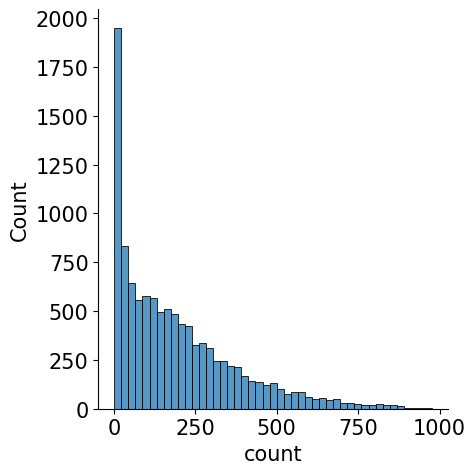

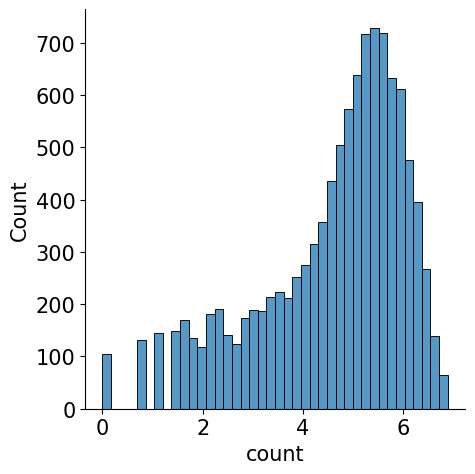

In [37]:
mpl.rc('font', size=15) # 폰트 크기를 15로 설정
sns.displot(train['count']);  #  분포도 출력
sns.displot(np.log(train['count'])) 

#### 범주형 데이터

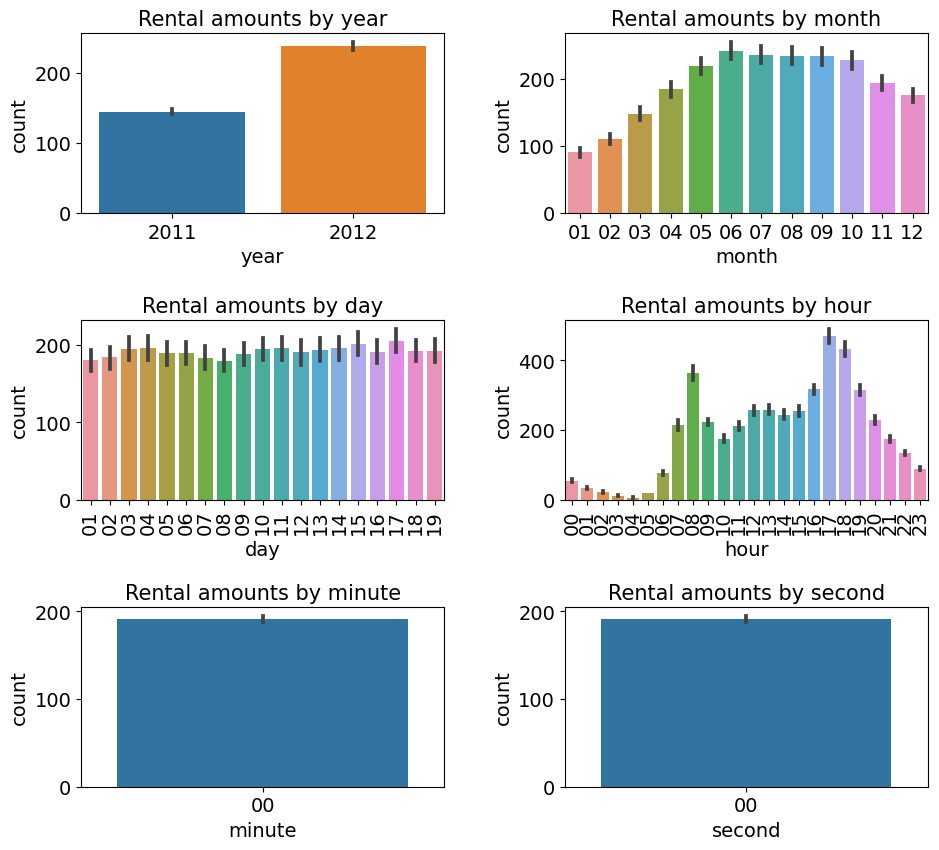

In [38]:
mpl.rc('font', size = 14)        #  폰트 크기 설정
mpl.rc('axes', titlesize=15)    #  각 축의 제목 크기 설정
figure, axes = plt.subplots(nrows=3, ncols=2)   #  3행 2열 Figure 생성
plt.tight_layout()             #  그래프 사이에 여백 확보
figure.set_size_inches(10, 9)  #  전체 Figure 크기를 10 x 9 인치로 설정

sns.barplot(x='year', y='count', data=train, ax=axes[0, 0])
sns.barplot(x='month', y='count', data=train, ax=axes[0, 1])
sns.barplot(x='day', y='count', data=train, ax=axes[1, 0])
sns.barplot(x='hour', y='count', data=train, ax=axes[1, 1])
sns.barplot(x='minute', y='count', data=train, ax=axes[2, 0])
sns.barplot(x='second', y='count', data=train, ax=axes[2, 1])

axes[0, 0].set(title='Rental amounts by year')
axes[0, 1].set(title='Rental amounts by month')
axes[1, 0].set(title='Rental amounts by day')
axes[1, 1].set(title='Rental amounts by hour')
axes[2, 0].set(title='Rental amounts by minute')
axes[2, 1].set(title='Rental amounts by second')

axes[1, 0].tick_params(axis='x', labelrotation=90)
axes[1, 1].tick_params(axis='x', labelrotation=90)

#### 범주형 데이터에 따르는 수치형 데이터

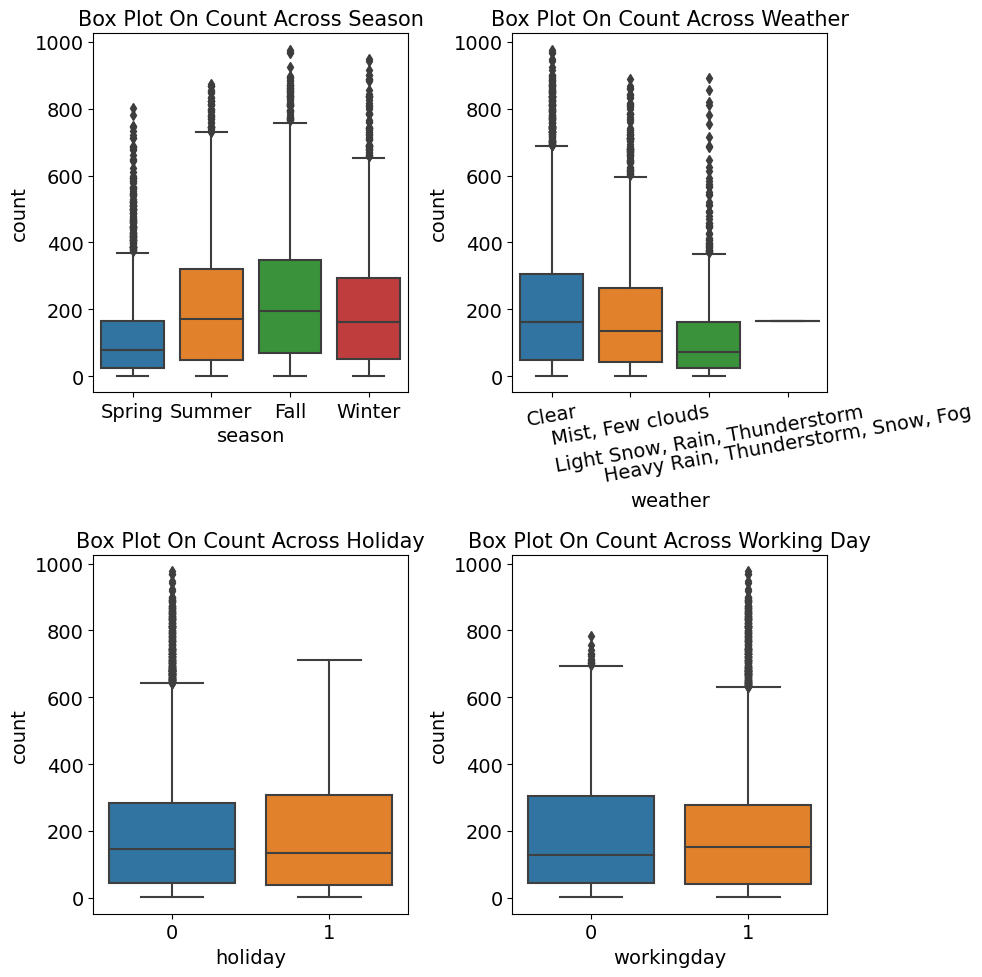

In [39]:
# 스텝 1: m행 n열 Figure 준비

figure, axes = plt.subplots(nrows=2, ncols=2)
figure.set_size_inches(10, 10)

# 스텝 2: 서브플롯 할당
# 계절, 날씨, 공휴일, 근무일별 대여 수량 박스플롯
sns.boxplot(x='season', y='count', data=train, ax=axes[0, 0])
sns.boxplot(x='weather', y='count', data=train, ax=axes[0, 1])
sns.boxplot(x='holiday', y='count', data=train, ax=axes[1, 0])
sns.boxplot(x='workingday', y='count', data=train, ax=axes[1, 1])

# 스텝 3: 세부 설정
# 3-1: 서브플롯에 제목 달기
axes[0, 0].set(title='Box Plot On Count Across Season')
axes[0, 1].set(title='Box Plot On Count Across Weather')
axes[1, 0].set(title='Box Plot On Count Across Holiday')
axes[1, 1].set(title='Box Plot On Count Across Working Day')

axes[0, 1].tick_params(axis='x', labelrotation=10)

plt.tight_layout()

<Axes: xlabel='hour', ylabel='count'>

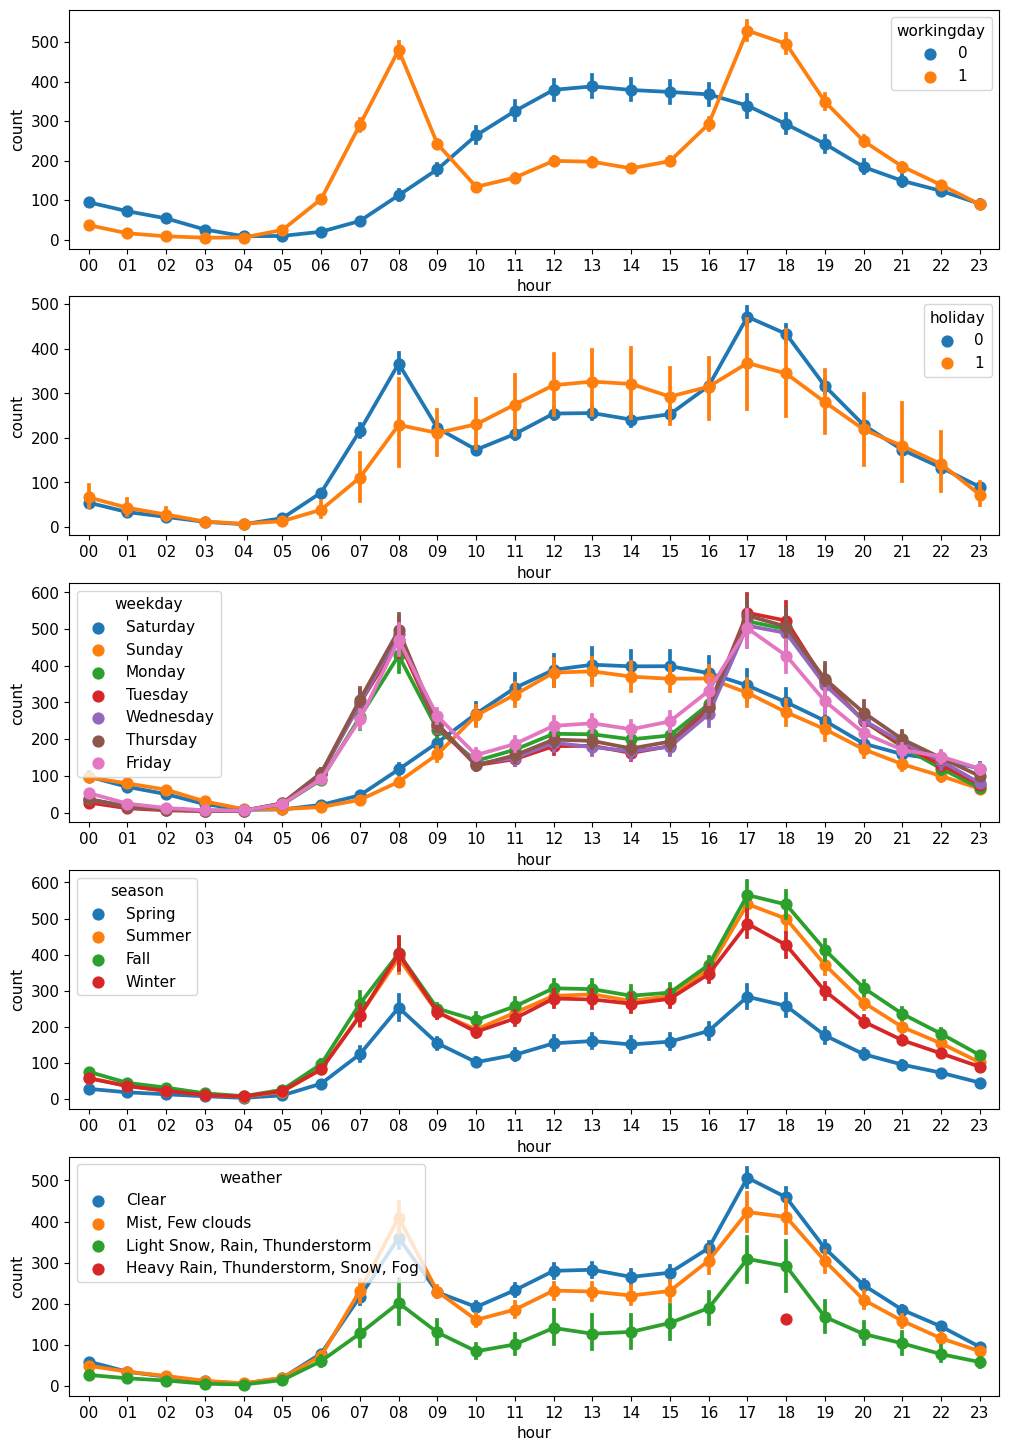

In [40]:
# 스텝 1: m행 n열 Figure 준비
mpl.rc('font', size=11)
figure, axes = plt.subplots(nrows=5) # 5행 1열
figure.set_size_inches(12, 18)

# 스텝 2: 서브플롯 할당
# 근무일, 공휴일, 요일, 계절, 날씨에 따른 시간대별 평균 대여 수량 포인트플롯
sns.pointplot(x='hour', y='count', data=train, hue='workingday', ax=axes[0])
sns.pointplot(x='hour', y='count', data=train, hue='holiday', ax=axes[1])
sns.pointplot(x='hour', y='count', data=train, hue='weekday', ax=axes[2])
sns.pointplot(x='hour', y='count', data=train, hue='season', ax=axes[3])
sns.pointplot(x='hour', y='count', data=train, hue='weather', ax=axes[4])

- `weather` 빨간색 점은 이상치.

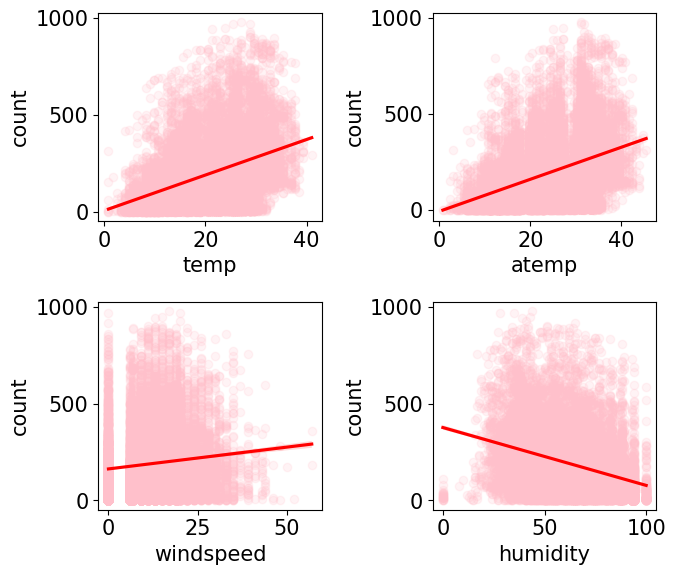

In [41]:
# 스텝 1: m행 n열 Figure 준비
mpl.rc('font', size=15)
figure, axes = plt.subplots(nrows=2, ncols=2) # 2형 2열
figure.set_size_inches(7, 6)

# 스텝 2: 서브플롯 할당
# 온도, 체감 온도, 풍속, 습도 별 대여 수량 산점도 그래프
sns.regplot(x='temp', y='count', data=train, ax=axes[0, 0], scatter_kws={'alpha':0.18, 'color':'pink'}, line_kws={'color':'red'})
sns.regplot(x='atemp', y='count', data=train, ax=axes[0, 1], scatter_kws={'alpha':0.18, 'color':'pink'}, line_kws={'color':'red'})
sns.regplot(x='windspeed', y='count', data=train, ax=axes[1, 0], scatter_kws={'alpha':0.18, 'color':'pink'}, line_kws={'color':'red'})
sns.regplot(x='humidity', y='count', data=train, ax=axes[1, 1], scatter_kws={'alpha':0.18, 'color':'pink'}, line_kws={'color':'red'})

plt.tight_layout()

- `windspeed` 데이터 값이 `0`이 많음
  - 실제 풍속이 0이 아니라 관측치가 없거나, 오류로 인해 0으로 기록됐을 가능성이 높음.
  - 결측값이 많은 경우 대체하거나 feature 자체를 삭제하는 것이 좋음

[Text(0.5, 1.0, 'Heatmap of Numerical Data')]

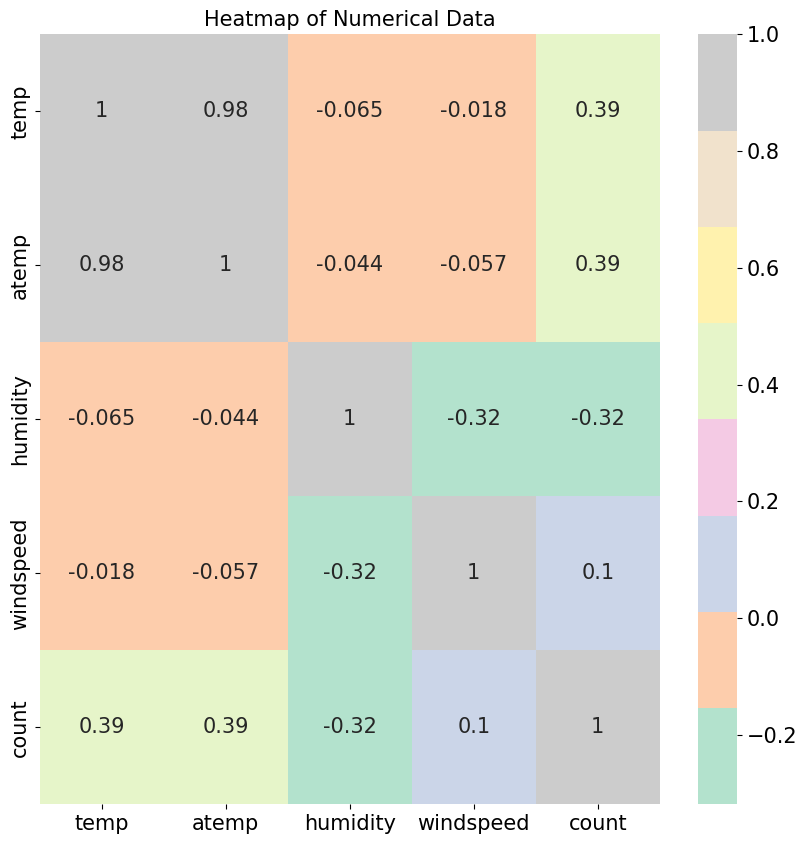

In [42]:
# 피쳐 간 상관관계 매트릭스
train[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()

corrMat = train[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sns.heatmap(corrMat, annot=True, cmap='Pastel2') # 상관관계 히트맵 그리기
ax.set(title='Heatmap of Numerical Data')

## Modelling

### Baseline Model - Linear Regression

#### Reload Data Set

In [43]:
import numpy as np       # 넘파이 임포트
import pandas as pd      # 판다스 임포트

data_path = '/kaggle/input/bike-sharing-demand/'             # 데이터 경로

train = pd.read_csv(data_path + 'train.csv')                 # 훈련 데이터
test = pd.read_csv(data_path + 'test.csv')                   # 테스트 데이터
submission = pd.read_csv(data_path + 'sampleSubmission.csv') # 제출 샘플 데이터

#### Preprocessing

In [44]:
# 훈련 데이터에서 w e a t h e r 가 4 가 아닌 데이터만 추출
train = train[train['weather'] != 4]

In [45]:
# `Feature engineering`을 위해 학습용 데이터, 테스트용 데이터셋 병합
all_data = pd.concat([train, test], ignore_index = True)
all_data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
17373,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17374,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17375,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN
17376,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN


#### Feature Selection

In [46]:
from datetime import datetime

all_data['date'] = all_data['datetime'].apply(lambda x: x.split()[0])                             # '날짜' 피처 생성
all_data['year'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[0])               # '연도' 피처 생성
all_data['month'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[1])              # '월' 피처 생성
all_data['hour'] = all_data['datetime'].apply(lambda x: x.split()[1].split(':')[0])               # '시' 피처 생성
all_data['weekday'] = all_data['date'].apply(lambda dateString:
                                             datetime.strptime(dateString, "%Y-%m-%d").weekday()) # '요일' 피처 생성

In [47]:
drop_features = ['casual', 'registered', 'datetime', 'date', 'month', 'windspeed']

all_data = all_data.drop(drop_features, axis=1)

In [48]:
# 훈련 데이터와 테스트 데이터 나누기
X_train = all_data[~pd.isnull(all_data['count'])]
X_test = all_data[pd.isnull(all_data['count'])]

# 타깃값 count 제거
X_train = X_train.drop(['count'], axis=1)
X_test = X_test.drop(['count'], axis=1)

y = train['count']  #  타깃값

X_train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,year,hour,weekday
0,1,0,0,1,9.84,14.395,81,2011,00,5
1,1,0,0,1,9.02,13.635,80,2011,01,5
2,1,0,0,1,9.02,13.635,80,2011,02,5
3,1,0,0,1,9.84,14.395,75,2011,03,5
4,1,0,0,1,9.84,14.395,75,2011,04,5


#### 평가지표(RMSLE) 계산 함수 작성

##### RMSLE (Root Mean Squared Logarithmic Error)

$$
\text{RMSLE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (\log(p_i + 1) - \log(a_i + 1))^2}
$$

- 특징
  - 절대 오차가 아니라 “로그 변환된 값의 차이”를 보기 때문에, 값의 크기보다 상대적인 비율 차이에 더 민감하게 반응한다.​
  - 값이 클수록 오차가 커지는 RMSE에 비해, RMSLE는 큰 값에서의 큰 오차 영향이 완화되고 이상치에 덜 민감한 편이다.​
  - 예측이 실제보다 작은 경우(언더프레딕션)에 더 큰 패널티를 주는 경향이 있어, 수요·재고 예측처럼 모자라면 곤란한 문제에서 자주 쓰인다.​

- 언제 사용하면 좋은가
  - 타깃이 0 이상이며 분포가 한쪽으로 치우쳐 있고, 값의 규모가 클수록 오차의 절대값도 커지는 수요·매출·트래픽 예측 같은 문제에 적합하다.​
  - “실제의 2배로 예측”과 “실제의 절반으로 예측”을 비슷한 수준의 실수로 취급하고 싶을 때, 즉 비율 기반 성능이 중요한 경우에 적합하다.

In [49]:
def rmsle(y_true, y_pred, convertExp=True):
    #  지수변환 1
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
    
    # 로그변환 후 결측값을 0으로 변환
    log_true = np.nan_to_num(np.log(y_true + 1))
    log_pred = np.nan_to_num(np.log(y_pred + 1))

    # RMSLE 계산
    output = np.sqrt(np.mean((log_true - log_pred) ** 2))
    
    return output

In [50]:
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression()

log_y = np.log(y)                     # 타깃값 로그변환
linear_reg_model.fit(X_train, log_y)  # 모델 훈련

LinearRegression()

In [51]:
preds = linear_reg_model.predict(X_train)

In [52]:
print(f'선형회귀의 RMSLE 값: {rmsle(log_y, preds, True):.4f}')

선형회귀의 RMSLE 값: 1.0205


In [53]:
linearreg_preds = linear_reg_model.predict(X_test)  #  테스트 데이터로 예측

submission['count'] = np.exp(linearreg_preds)     #  지수변환

submission.to_csv('submission.csv', index=False)  #  파일로 저장